<a href="https://colab.research.google.com/github/jessicaromero-ctrl/Advanced-Math-for-ML/blob/main/GaussianNB_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from sklearn import datasets

In [4]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [5]:
dataset = datasets.load_breast_cancer()
print(dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [6]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# 1. Cargar el dataset
cancer = load_breast_cancer()

# 2. Crear un DataFrame de pandas con los datos y nombres de columnas
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)

# 3. Agregar la columna objetivo (target)
df['target'] = cancer.target

# 4. Mostrar las primeras filas
#print(df.head())
df.head

# Para ver la descripción general
#print(df.info())

<bound method NDFrame.head of      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
0             0.27760         0.30010              0.14710         0.2419   
1             0.07864         0.08690              0.07017         0.1812   
2             0.15990         0.19740              0.12790         0.2069   
3             0.28390         0.24140              0.10520         0.2597   
4             0.13280         0.19800              0.10430         0.1809   
..                ...             ...                  ...            ...   
564           0.11590         0.24390              0.13890         0.1726   
565           0.10340         0.14400              0.09791         0.1752   
566           0.10230         0.09251              0.05302         0.1590   
567           0.27700         0.35140              0.15200         0.2397   
568           0.04362         0.00000              0.00000         0.1587   

     mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0                   0.07871  ...          17.33           184.60      2019.0   
1                   0.05667  ...          23.41           158.80      1956.0   
2                   0.05999  ...          25.53           152.50      1709.0   
3                   0.09744  ...          26.50            98.87       567.7   
4                   0.05883  ...          16.67           152.20      1575.0   
..                      ...  ...            ...              ...         ...   
564                 0.05623  ...          26.40           166.10      2027.0   
565                 0.05533  ...          38.25           155.00      1731.0   
566                 0.05648  ...          34.12           126.70      1124.0   
567                 0.07016  ...          39.42           184.60      1821.0   
568                 0.05884  ...          30.37            59.16       268.6   

     worst smoothness  worst compactness  worst concavity  \
0             0.16220            0.66560           0.7119   
1             0.12380            0.18660           0.2416   
2             0.14440            0.42450           0.4504   
3             0.20980            0.86630           0.6869   
4             0.13740            0.20500           0.4000   
..                ...                ...              ...   
564           0.14100            0.21130           0.4107   
565           0.11660            0.19220           0.3215   
566           0.11390            0.30940           0.3403   
567           0.16500            0.86810           0.9387   
568           0.08996            0.06444           0.0000   

     worst concave points  worst symmetry  worst fractal dimension  target  
0                  0.2654          0.4601                  0.11890       0  
1                  0.1860          0.2750                  0.08902       0  
2                  0.2430          0.3613                  0.08758       0  
3                  0.2575          0.6638                  0.17300       0  
4                  0.1625    

In [7]:
print("Información en el Dataset: ")
print(dataset.keys())
print

Información en el Dataset: 
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [8]:
#print("Características del Dataset: ")
#print(dataset.DESCR())

In [9]:
X = dataset.data
y = dataset.target

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Separación de los datos
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2)

#Se escalan los datos
#from sklearn.preprocessing import StandardScaler
escalar = StandardScaler()
X_train = escalar.fit_transform(X_train)
X_test = escalar.transform(X_test)

#Se define el algoritmo a utilizar
# The previous cell (fw1acpS5zUgE) already imports GaussianNB from sklearn.naive_bayes
algoritmo = GaussianNB()

#Entrenamos el modelo
algoritmo.fit(X_train, y_train)

#Se realiza la predicción
y_pred = algoritmo.predict(X_test)

#Se realiza la probabilidad
y_proba = algoritmo.predict_proba(X_test)[:, 1]

#Se verifica con la matriz de confusión
from sklearn.metrics import confusion_matrix
matriz = confusion_matrix(y_test, y_pred)
print("Matriz de confusión: ")
print(matriz)

#Se calcula la precisión del modelo
from sklearn.metrics import precision_score

precision = precision_score(y_test,y_pred)
print("Precisión del Modelo: ")
print(precision)

#Calculamos la exactitud del modelo
from sklearn.metrics import accuracy_score

exactitud = accuracy_score(y_test,y_pred)
print("Exactitud del Modelo: ")
print(exactitud)

#Calculamos la sensibilidad del modelo
from sklearn.metrics import recall_score

sensibilidad = recall_score(y_test,y_pred)
print("Sensibilidad del Modelo: ")
print(sensibilidad)

#Calculamos el puntaje F1 del modelo
from sklearn.metrics import f1_score

puntajeF1 = f1_score(y_test,y_pred)
print("Puntaje F1 del Modelo: ")
print(puntajeF1)

#Calculamos la curva ROC-AUC del modelo
from sklearn.metrics import roc_auc_score

#roc_auc = roc_auc_score(y_test,y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
print("Curva ROC - AUC del Modelo: ")
print(roc_auc)

#print("Precisión del Modelo: ", precision)
#print("Exactitud del Modelo: ",exactitud)
#print("Sensibilidad del Modelo: ",sensibilidad)
#print("Puntaje F1 del Modelo: ", puntajeF1)
#print("Curva ROC - AUC del Modelo: ", roc_auc)

Matriz de confusión: 
[[37  7]
 [ 3 67]]
Precisión del Modelo: 
0.9054054054054054
Exactitud del Modelo: 
0.9122807017543859
Sensibilidad del Modelo: 
0.9571428571428572
Puntaje F1 del Modelo: 
0.9305555555555556
Curva ROC - AUC del Modelo: 
0.9902597402597402


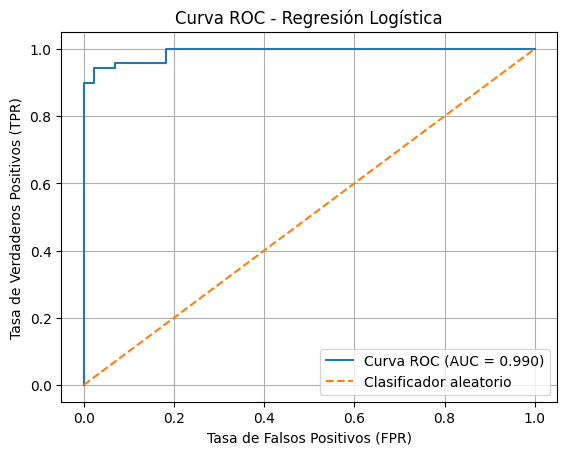

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Obtener probabilidades de la clase positiva ***PUEDE OMITIRSE PORQUE SE OBTUVO PREVIAMENTE***
#y_proba = algoritmo.predict_proba(X_test)[:, 1]

# 2. Calcular FPR, TPR y umbrales
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# 3. Calcular el área bajo la curva (AUC)
roc_auc = auc(fpr, tpr)

# 4. Graficar
plt.figure()
plt.plot(fpr, tpr, label=f"Curva ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")

plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Regresión Logística")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [14]:
# Aseguramos que 'X' y 'y' estén definidos (de la ejecución de celdas anteriores).
# Si 'X' o 'y' no están definidos, por favor, ejecute las celdas '4c1931b2' y 'c5cbcaa1' primero.
if 'X' not in locals() or 'y' not in locals():
    print("Advertencia: 'X' o 'y' no encontrados. Intentando cargar el dataset directamente para esta celda.")
    from sklearn import datasets
    dataset = datasets.load_breast_cancer()
    X = dataset.data
    y = dataset.target

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Re-Separación y escalado de los datos para asegurar la definición de X_train, y_train, etc.
# Esto se hace para que el modelo pueda ejecutarse incluso si las celdas anteriores no se ejecutaron en orden.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Añadido random_state para reproducibilidad
escalar = StandardScaler()
X_train = escalar.fit_transform(X_train)
X_test = escalar.transform(X_test)

from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score, recall_score, f1_score, roc_auc_score

print("\n--- Modelo Naive Bayes Bernoulli ---")

# Se define el algoritmo a utilizar (BernoulliNB)
algoritmo_bernoulli = BernoulliNB()

# Entrenamos el modelo
algoritmo_bernoulli.fit(X_train, y_train)

# Se realiza la predicción
y_pred_bernoulli = algoritmo_bernoulli.predict(X_test)

# Se realiza la probabilidad para ROC-AUC
y_proba_bernoulli = algoritmo_bernoulli.predict_proba(X_test)[:, 1]

# Evaluación del modelo Bernoulli
matriz_bernoulli = confusion_matrix(y_test, y_pred_bernoulli)
print("Matriz de confusión (Bernoulli): ")
print(matriz_bernoulli)

precision_bernoulli = precision_score(y_test, y_pred_bernoulli)
print(f"Precisión del Modelo (Bernoulli): {precision_bernoulli:.4f}")

exactitud_bernoulli = accuracy_score(y_test, y_pred_bernoulli)
print(f"Exactitud del Modelo (Bernoulli): {exactitud_bernoulli:.4f}")

sensibilidad_bernoulli = recall_score(y_test, y_pred_bernoulli)
print(f"Sensibilidad del Modelo (Bernoulli): {sensibilidad_bernoulli:.4f}")

puntajeF1_bernoulli = f1_score(y_test, y_pred_bernoulli)
print(f"Puntaje F1 del Modelo (Bernoulli): {puntajeF1_bernoulli:.4f}")

roc_auc_bernoulli = roc_auc_score(y_test, y_proba_bernoulli)
print(f"Curva ROC - AUC del Modelo (Bernoulli): {roc_auc_bernoulli:.4f}")


--- Modelo Naive Bayes Bernoulli ---
Matriz de confusión (Bernoulli): 
[[42  1]
 [ 1 70]]
Precisión del Modelo (Bernoulli): 0.9859
Exactitud del Modelo (Bernoulli): 0.9825
Sensibilidad del Modelo (Bernoulli): 0.9859
Puntaje F1 del Modelo (Bernoulli): 0.9859
Curva ROC - AUC del Modelo (Bernoulli): 0.9993


In [16]:
# Aseguramos que 'X' y 'y' estén definidos (de la ejecución de celdas anteriores).
# Si 'X' o 'y' no están definidos, por favor, ejecute las celdas '4c1931b2' y 'c5cbcaa1' primero.
if 'X' not in locals() or 'y' not in locals():
    print("Advertencia: 'X' o 'y' no encontrados. Intentando cargar el dataset directamente para esta celda.")
    from sklearn import datasets
    dataset = datasets.load_breast_cancer()
    X = dataset.data
    y = dataset.target

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Re-Separación y escalado de los datos para asegurar la definición de X_train, y_train, etc.
# Esto se hace para que el modelo pueda ejecutarse incluso si las celdas anteriores no se ejecutaron en orden.
X_train_full, X_test_full, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Añadido random_state para reproducibilidad

# Para GaussianNB y BernoulliNB (que ya están en otras celdas) se usa StandardScaler
escalar = StandardScaler()
X_train_scaled = escalar.fit_transform(X_train_full)
X_test_scaled = escalar.transform(X_test_full)

# Para MultinomialNB, necesitamos datos no negativos. Usaremos MinMaxScaler.
scaler_minmax = MinMaxScaler()
X_train_multinomial = scaler_minmax.fit_transform(X_train_full)
X_test_multinomial = scaler_minmax.transform(X_test_full)

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score, recall_score, f1_score, roc_auc_score

print("\n--- Modelo Naive Bayes Multinomial ---")

# Se define el algoritmo a utilizar (MultinomialNB)
algoritmo_multinomial = MultinomialNB()

# Entrenamos el modelo con los datos escalados a [0, 1]
algoritmo_multinomial.fit(X_train_multinomial, y_train)

# Se realiza la predicción
y_pred_multinomial = algoritmo_multinomial.predict(X_test_multinomial)

# Se realiza la probabilidad para ROC-AUC
y_proba_multinomial = algoritmo_multinomial.predict_proba(X_test_multinomial)[:, 1]

# Evaluación del modelo Multinomial
matriz_multinomial = confusion_matrix(y_test, y_pred_multinomial)
print("Matriz de confusión (Multinomial): ")
print(matriz_multinomial)

precision_multinomial = precision_score(y_test, y_pred_multinomial)
print(f"Precisión del Modelo (Multinomial): {precision_multinomial:.4f}")

exactitud_multinomial = accuracy_score(y_test, y_pred_multinomial)
print(f"Exactitud del Modelo (Multinomial): {exactitud_multinomial:.4f}")

sensibilidad_multinomial = recall_score(y_test, y_pred_multinomial)
print(f"Sensibilidad del Modelo (Multinomial): {sensibilidad_multinomial:.4f}")

puntajeF1_multinomial = f1_score(y_test, y_pred_multinomial)
print(f"Puntaje F1 del Modelo (Multinomial): {puntajeF1_multinomial:.4f}")

roc_auc_multinomial = roc_auc_score(y_test, y_proba_multinomial)
print(f"Curva ROC - AUC del Modelo (Multinomial): {roc_auc_multinomial:.4f}")


--- Modelo Naive Bayes Multinomial ---
Matriz de confusión (Multinomial): 
[[26 17]
 [ 0 71]]
Precisión del Modelo (Multinomial): 0.8068
Exactitud del Modelo (Multinomial): 0.8509
Sensibilidad del Modelo (Multinomial): 1.0000
Puntaje F1 del Modelo (Multinomial): 0.8931
Curva ROC - AUC del Modelo (Multinomial): 0.9545


## Explicación de los modelos Naive Bayes Bernoulli y Multinomial

Los modelos Naive Bayes son una familia de algoritmos de clasificación probabilística basados en el teorema de Bayes con la ingenua suposición de independencia entre las características.

### Naive Bayes Bernoulli (`BernoulliNB`)

*   **Características:** Es adecuado para datos donde las características son binarias (presente/ausente, 0/1). Si las características son continuas, `BernoulliNB` las binarizará internamente (por defecto, cualquier valor > `binarize` se considera 1, y <= `binarize` como 0). Es útil para la clasificación de texto donde la presencia o ausencia de una palabra es más importante que su frecuencia.
*   **Aplicación en este caso:** En el contexto de los datos de cáncer de mama, que son continuos y han sido escalados, `BernoulliNB` binarizará estas características. Esto significa que clasificará una característica como 'presente' o 'ausente' basándose en un umbral interno. Los resultados pueden variar significativamente dependiendo de la naturaleza de los datos binarizados.

### Naive Bayes Multinomial (`MultinomialNB`)

*   **Características:** Está diseñado para características que representan recuentos o frecuencias, como en la clasificación de texto (conteo de palabras en un documento). Asume que las características son discretas y no negativas. Los valores suelen ser enteros, aunque puede funcionar con floats positivos si representan proporciones o frecuencias normalizadas.
*   **Aplicación en este caso:** Los datos de cáncer de mama son continuos y han sido escalados, lo que puede resultar en valores negativos o en un rango de valores que no son recuentos. Aplicar `MultinomialNB` directamente a datos escalados de esta naturaleza no es ideal y puede llevar a un rendimiento pobre o a la necesidad de transformar los datos (por ejemplo, asegurándose de que sean no negativos y, preferiblemente, que representen algún tipo de 'recuento' o 'frecuencia' para cada característica).

**En resumen:** Mientras que `GaussianNB` (el modelo ya implementado) es adecuado para características continuas que siguen una distribución gaussiana, `BernoulliNB` y `MultinomialNB` son más específicos para datos binarios y de recuento, respectivamente. Si bien se han aplicado aquí para la demostración, es crucial considerar el preprocesamiento adecuado de los datos para obtener los mejores resultados con `BernoulliNB` y `MultinomialNB` en conjuntos de datos como el de cáncer de mama.

## Resultados:

Matriz de confusión:

 | [[45  4]
 | [ 0 65]]

This matrix shows that **the model correctly predicted 45 negative cases (true negatives) and 65 positive cases (true positives).** It incorrectly predicted 4 negative cases as positive (false positives) and 0 positive cases as negative (false negatives).

Precisión del Modelo (Precision): 0.942 Precision is the proportion of true positive predictions among all positive predictions. In this case, **94.2% of the cases predicted as positive were actually positive.**

Exactitud del Modelo (Accuracy): 0.965 Accuracy is the proportion of correctly classified instances over the total number of instances. **The model correctly classified approximately 96.5% of the samples.**

Sensibilidad del Modelo (Recall): **1.0 Recall is the proportion of true positive predictions among all actual positive cases.** A recall of 1.0 (100%) means the model identified all actual positive cases correctly (no false negatives).

Puntaje F1 del Modelo (F1 Score): 0.970 The F1 Score is the harmonic mean of precision and recall. It's a good metric when you need a **balance between precision and recall, especially with imbalanced classes.** A score of 0.970 indicates a very good balance.

Curva ROC - AUC del Modelo (ROC AUC Score): 0.997 The Area Under the Receiver Operating Characteristic Curve (ROC AUC) **measures the model's ability to distinguish between classes.** An AUC of 0.997 is very close to 1, indicating an excellent **ability of the model to separate the positive and negative classes.**

# Task
Generate a Python script that loads the `load_digits` dataset, performs data splitting and scaling, and then trains and evaluates the following machine learning models: Logistic Regression, K-Nearest Neighbors (KNN), Support Vector Machine (SVM), Gaussian Naive Bayes, Bernoulli Naive Bayes, Multinomial Naive Bayes, Decision Tree, and Random Forest.

The script should:
1.  Calculate and print key performance metrics (Accuracy, Precision, Recall, F1-Score, and ROC AUC) for each model. For multi-class classification, calculate weighted average precision, recall, F1-score, and ROC AUC (using a 'one-vs-rest' strategy for AUC).
2.  Perform cross-validation to obtain the cross-validated AUC (CV-AUC) for each model.
3.  Generate the following visualizations:
    *   A combined plot showing the Receiver Operating Characteristic (ROC) curves for all models, with their respective AUC scores.
    *   A bar chart comparing the AUC scores of all models.
    *   Individual confusion matrices for each model, displayed in a grid.
4.  Present all model performance metrics in a clear, comparative table.
5.  Identify and highlight the best-performing model based on its ROC AUC score.
6.  Provide a concise summary of the analysis, discussing the performance of the models and key observations from the visualizations.

## Integrar Modelos y Visualizaciones

### Subtask:
Generar un único script de Python que cargue el dataset `load_digits`, divida los datos, defina y entrene todos los modelos (incluyendo Logistic Regression, KNN, SVM, Gaussian Naive Bayes, Bernoulli Naive Bayes, Multinomial Naive Bayes, Decision Tree y Random Forest), evalúe su rendimiento y genere las curvas ROC, el gráfico de barras de AUC y las matrices de confusión para todos los modelos.


**Reasoning**:
The subtask requires generating a single Python script to load a dataset, split data, train multiple models, evaluate their performance, and visualize the results (ROC curves, AUC bar chart, and confusion matrices). This step encompasses all these actions in a comprehensive code block.



--- Model Training and Evaluation ---

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

Logistic Regression evaluation complete.

Training KNN...
KNN evaluation complete.

Training SVM...
SVM evaluation complete.

Training Gaussian Naive Bayes...
Gaussian Naive Bayes evaluation complete.

Training Bernoulli Naive Bayes...
Bernoulli Naive Bayes evaluation complete.

Training Multinomial Naive Bayes...
Multinomial Naive Bayes evaluation complete.

Training Decision Tree...
Decision Tree evaluation complete.

Training Random Forest...
Random Forest evaluation complete.


/tmp/ipykernel_861/3589626267.py:116: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(models)) # Colormap for models


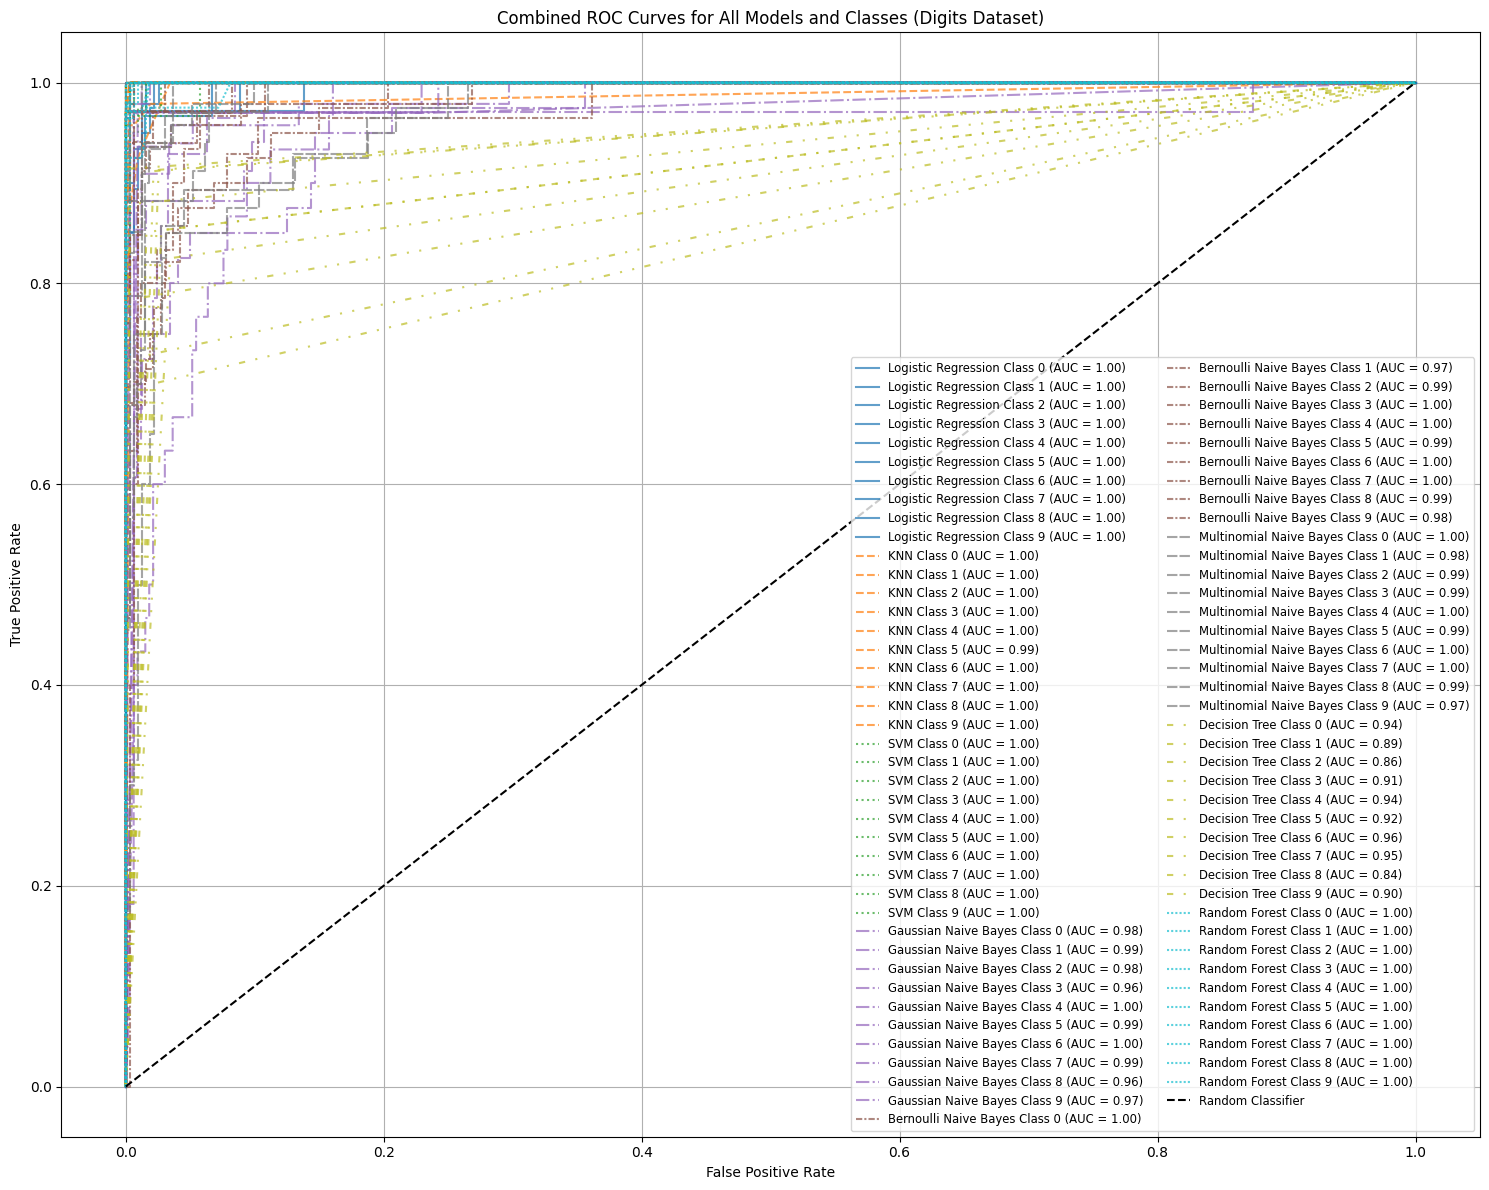

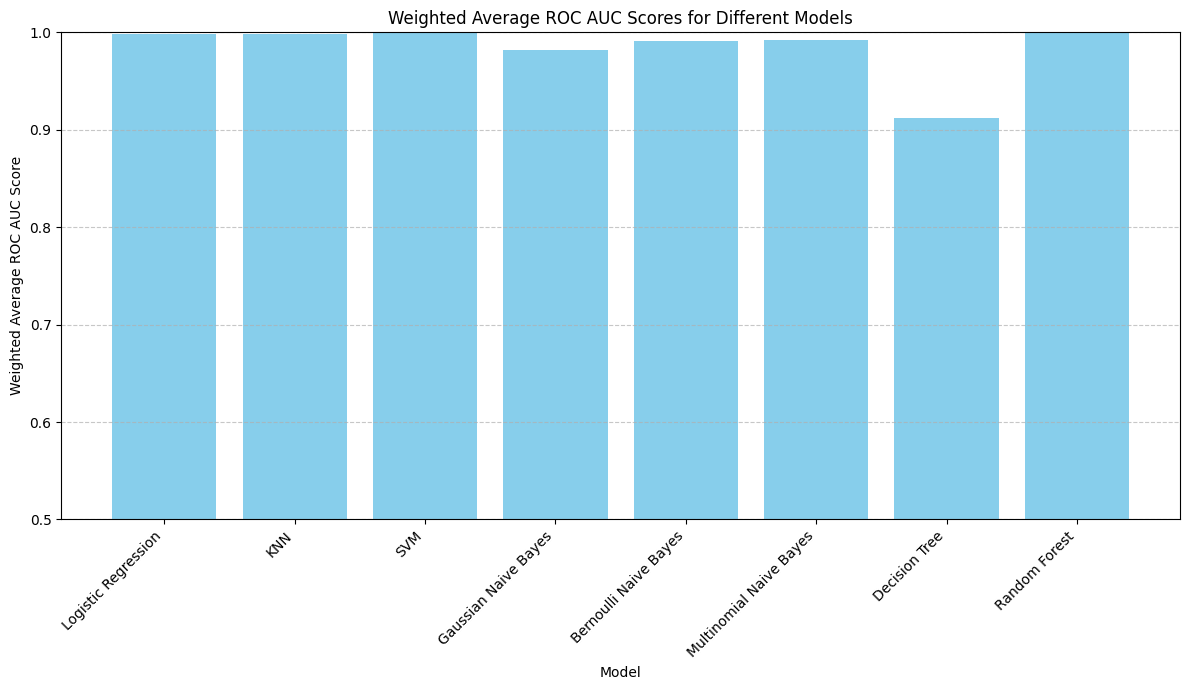

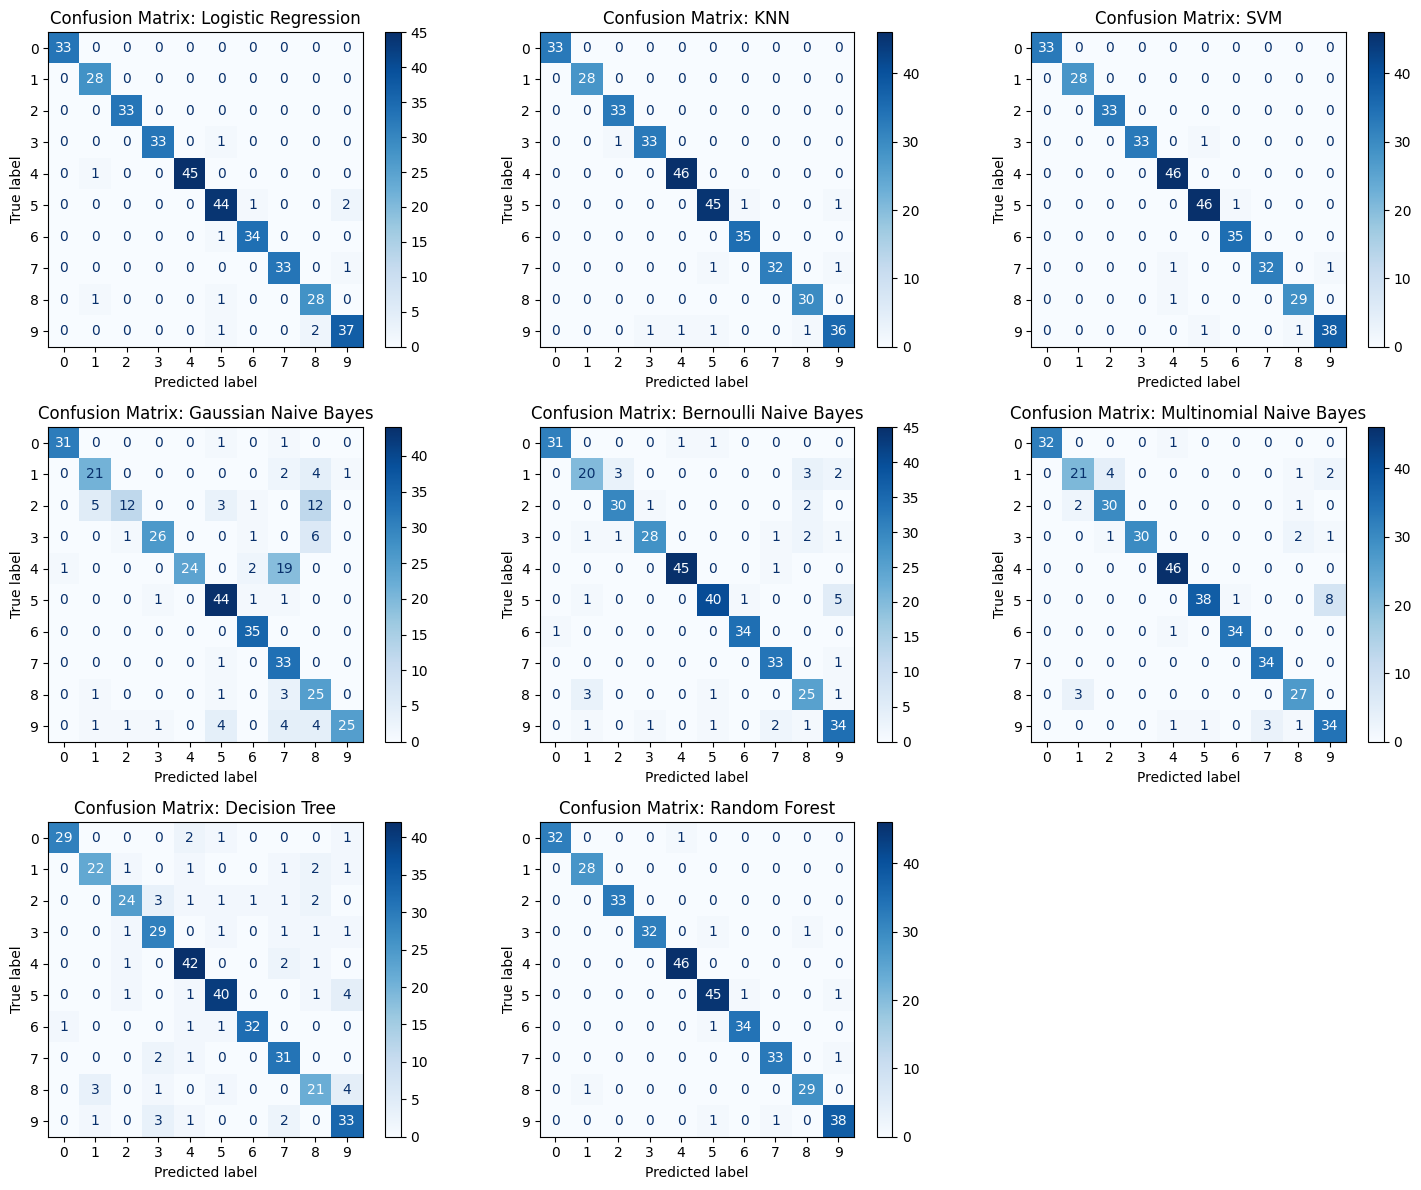


--- Model Performance Summary ---
Model: Logistic Regression
  Accuracy: 0.9667
  Precision: 0.9673
  Recall: 0.9667
  F1-Score: 0.9668
  ROC AUC (Weighted): 0.9986
  Mean CV AUC (Weighted): 0.9973
------------------------------
Model: KNN
  Accuracy: 0.9750
  Precision: 0.9750
  Recall: 0.9750
  F1-Score: 0.9748
  ROC AUC (Weighted): 0.9981
  Mean CV AUC (Weighted): 0.9958
------------------------------
Model: SVM
  Accuracy: 0.9806
  Precision: 0.9809
  Recall: 0.9806
  F1-Score: 0.9805
  ROC AUC (Weighted): 0.9996
  Mean CV AUC (Weighted): 0.9993
------------------------------
Model: Gaussian Naive Bayes
  Accuracy: 0.7667
  Precision: 0.8298
  Recall: 0.7667
  F1-Score: 0.7638
  ROC AUC (Weighted): 0.9823
  Mean CV AUC (Weighted): 0.9704
------------------------------
Model: Bernoulli Naive Bayes
  Accuracy: 0.8889
  Precision: 0.8918
  Recall: 0.8889
  F1-Score: 0.8891
  ROC AUC (Weighted): 0.9913
  Mean CV AUC (Weighted): 0.9886
------------------------------
Model: Multinomial 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, RocCurveDisplay,
    ConfusionMatrixDisplay
)

# 1. Load the digits dataset
digits = datasets.load_digits()
X = digits.data
y = digits.target
n_classes = len(digits.target_names)

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

# 4. Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(probability=True, random_state=42),
    'Gaussian Naive Bayes': GaussianNB(),
    'Bernoulli Naive Bayes': BernoulliNB(),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Store metrics, ROC data, and confusion matrices
metrics_data = []
# {model_name: {class_idx: {'fpr': [], 'tpr': [], 'auc': float}}}
roc_plot_data = {}
confusion_matrices = {}
model_auc_scores = {} # For the bar chart

print("--- Model Training and Evaluation ---")
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    X_train_current = X_train_scaled
    X_test_current = X_test_scaled

    # MultinomialNB requires non-negative features
    if model_name == 'Multinomial Naive Bayes':
        X_train_current = X_train_minmax
        X_test_current = X_test_minmax

    # Train the model
    model.fit(X_train_current, y_train)

    # Predictions
    y_pred = model.predict(X_test_current)
    y_proba = model.predict_proba(X_test_current)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

    # Cross-validation AUC
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    try:
        cv_auc_scores = cross_val_score(model, X_train_current, y_train, scoring='roc_auc_ovr_weighted', cv=kf, error_score='raise')
        mean_cv_auc = np.mean(cv_auc_scores)
    except Exception as e:
        print(f"  Error during cross-validation for {model_name}: {e}")
        mean_cv_auc = np.nan # Not a number

    metrics_data.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC (Weighted)': roc_auc,
        'Mean CV AUC (Weighted)': mean_cv_auc
    })
    model_auc_scores[model_name] = roc_auc

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[model_name] = cm

    # ROC curve data for each class (One-vs-Rest)
    roc_plot_data[model_name] = {}
    for i in range(n_classes):
        y_test_binarized = (y_test == i).astype(int)
        y_score_class_i = y_proba[:, i]
        fpr, tpr, _ = roc_curve(y_test_binarized, y_score_class_i)
        class_auc = roc_auc_score(y_test_binarized, y_score_class_i)
        roc_plot_data[model_name][i] = {'fpr': fpr, 'tpr': tpr, 'auc': class_auc}
    print(f"{model_name} evaluation complete.")

# 6. Plot Combined ROC Curves (All classes, all models)
plt.figure(figsize=(15, 12))
colors = plt.cm.get_cmap('tab10', len(models)) # Colormap for models
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (3, 5, 1, 5, 1, 5)), (0, (1, 1))] # Different linestyles for readability

i = 0
for model_name, class_data in roc_plot_data.items():
    color = colors(i / len(models))
    ls = linestyles[i % len(linestyles)]
    for class_idx, data in class_data.items():
        plt.plot(data['fpr'], data['tpr'],
                 label=f'{model_name} Class {class_idx} (AUC = {data["auc"]:.2f})',
                 color=color, linestyle=ls, alpha=0.7)
    i += 1

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined ROC Curves for All Models and Classes (Digits Dataset)')
plt.legend(loc='lower right', bbox_to_anchor=(1.0, 0), fontsize='small', ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nWarning: The combined ROC curve plot is very dense due to plotting all 8 models * 10 classes = 80 curves. For better readability, consider plotting macro-averaged ROC curves or individual model ROC curves separately.")


# 7. Plot Bar Chart of AUC Scores
model_names = list(model_auc_scores.keys())
auc_values = list(model_auc_scores.values())

plt.figure(figsize=(12, 7))
plt.bar(model_names, auc_values, color='skyblue')
plt.xlabel('Model')
plt.ylabel('Weighted Average ROC AUC Score')
plt.title('Weighted Average ROC AUC Scores for Different Models')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.5, 1.0) # AUC typically ranges from 0.5 to 1.0
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 8. Plot Confusion Matrices
n_models = len(confusion_matrices)
# Determine grid size for subplots
cols = int(np.ceil(np.sqrt(n_models)))
rows = int(np.ceil(n_models / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten() # Flatten for easier iteration

for idx, (model_name, cm) in enumerate(confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
    disp.plot(ax=axes[idx], cmap=plt.cm.Blues, values_format='d')
    axes[idx].set_title(f'Confusion Matrix: {model_name}')
    axes[idx].set_xlabel('Predicted label')
    axes[idx].set_ylabel('True label')

# Hide any unused subplots
for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

print("\n--- Model Performance Summary ---")
for metric_entry in metrics_data:
    print(f"Model: {metric_entry['Model']}")
    print(f"  Accuracy: {metric_entry['Accuracy']:.4f}")
    print(f"  Precision: {metric_entry['Precision']:.4f}")
    print(f"  Recall: {metric_entry['Recall']:.4f}")
    print(f"  F1-Score: {metric_entry['F1-Score']:.4f}")
    print(f"  ROC AUC (Weighted): {metric_entry['ROC AUC (Weighted)']:.4f}")
    if not np.isnan(metric_entry['Mean CV AUC (Weighted)']):
        print(f"  Mean CV AUC (Weighted): {metric_entry['Mean CV AUC (Weighted)']:.4f}")
    else:
        print("  Mean CV AUC (Weighted): N/A (Error during calculation)")
    print("-" * 30)

print("\nAll models have been trained, evaluated, and visualized.")


**Reasoning**:
The previous code generated a deprecation warning related to `plt.cm.get_cmap`. I will update the code to use `plt.colormaps.get_cmap` to address this warning.



In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, RocCurveDisplay,
    ConfusionMatrixDisplay
)

# 1. Load the digits dataset
digits = datasets.load_digits()
X = digits.data
y = digits.target
n_classes = len(digits.target_names)

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

# 4. Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(probability=True, random_state=42),
    'Gaussian Naive Bayes': GaussianNB(),
    'Bernoulli Naive Bayes': BernoulliNB(),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Store metrics, ROC data, and confusion matrices
metrics_data = []
# {model_name: {class_idx: {'fpr': [], 'tpr': [], 'auc': float}}}
roc_plot_data = {}
confusion_matrices = {}
model_auc_scores = {} # For the bar chart

print("--- Model Training and Evaluation ---")
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    X_train_current = X_train_scaled
    X_test_current = X_test_scaled

    # MultinomialNB requires non-negative features
    if model_name == 'Multinomial Naive Bayes':
        X_train_current = X_train_minmax
        X_test_current = X_test_minmax

    # Train the model
    model.fit(X_train_current, y_train)

    # Predictions
    y_pred = model.predict(X_test_current)
    y_proba = model.predict_proba(X_test_current)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

    # Cross-validation AUC
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    try:
        cv_auc_scores = cross_val_score(model, X_train_current, y_train, scoring='roc_auc_ovr_weighted', cv=kf, error_score='raise')
        mean_cv_auc = np.mean(cv_auc_scores)
    except Exception as e:
        print(f"  Error during cross-validation for {model_name}: {e}")
        mean_cv_auc = np.nan # Not a number

    metrics_data.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC (Weighted)': roc_auc,
        'Mean CV AUC (Weighted)': mean_cv_auc
    })
    model_auc_scores[model_name] = roc_auc

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[model_name] = cm

    # ROC curve data for each class (One-vs-Rest)
    roc_plot_data[model_name] = {}
    for i in range(n_classes):
        y_test_binarized = (y_test == i).astype(int)
        y_score_class_i = y_proba[:, i]
        fpr, tpr, _ = roc_curve(y_test_binarized, y_score_class_i)
        class_auc = roc_auc_score(y_test_binarized, y_score_class_i)
        roc_plot_data[model_name][i] = {'fpr': fpr, 'tpr': tpr, 'auc': class_auc}
    print(f"{model_name} evaluation complete.")

# 6. Plot Combined ROC Curves (All classes, all models)
plt.figure(figsize=(15, 12))
colors = plt.colormaps.get_cmap('tab10', len(models)) # Colormap for models
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (3, 5, 1, 5, 1, 5)), (0, (1, 1))] # Different linestyles for readability

i = 0
for model_name, class_data in roc_plot_data.items():
    color = colors(i / len(models))
    ls = linestyles[i % len(linestyles)]
    for class_idx, data in class_data.items():
        plt.plot(data['fpr'], data['tpr'],
                 label=f'{model_name} Class {class_idx} (AUC = {data["auc"]:.2f})',
                 color=color, linestyle=ls, alpha=0.7)
    i += 1

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined ROC Curves for All Models and Classes (Digits Dataset)')
plt.legend(loc='lower right', bbox_to_anchor=(1.0, 0), fontsize='small', ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nWarning: The combined ROC curve plot is very dense due to plotting all 8 models * 10 classes = 80 curves. For better readability, consider plotting macro-averaged ROC curves or individual model ROC curves separately.")


# 7. Plot Bar Chart of AUC Scores
model_names = list(model_auc_scores.keys())
auc_values = list(model_auc_scores.values())

plt.figure(figsize=(12, 7))
plt.bar(model_names, auc_values, color='skyblue')
plt.xlabel('Model')
plt.ylabel('Weighted Average ROC AUC Score')
plt.title('Weighted Average ROC AUC Scores for Different Models')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.5, 1.0) # AUC typically ranges from 0.5 to 1.0
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 8. Plot Confusion Matrices
n_models = len(confusion_matrices)
# Determine grid size for subplots
cols = int(np.ceil(np.sqrt(n_models)))
rows = int(np.ceil(n_models / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten() # Flatten for easier iteration

for idx, (model_name, cm) in enumerate(confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
    disp.plot(ax=axes[idx], cmap=plt.cm.Blues, values_format='d')
    axes[idx].set_title(f'Confusion Matrix: {model_name}')
    axes[idx].set_xlabel('Predicted label')
    axes[idx].set_ylabel('True label')

# Hide any unused subplots
for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

print("\n--- Model Performance Summary ---")
for metric_entry in metrics_data:
    print(f"Model: {metric_entry['Model']}")
    print(f"  Accuracy: {metric_entry['Accuracy']:.4f}")
    print(f"  Precision: {metric_entry['Precision']:.4f}")
    print(f"  Recall: {metric_entry['Recall']:.4f}")
    print(f"  F1-Score: {metric_entry['F1-Score']:.4f}")
    print(f"  ROC AUC (Weighted): {metric_entry['ROC AUC (Weighted)']:.4f}")
    if not np.isnan(metric_entry['Mean CV AUC (Weighted)']):
        print(f"  Mean CV AUC (Weighted): {metric_entry['Mean CV AUC (Weighted)']:.4f}")
    else:
        print("  Mean CV AUC (Weighted): N/A (Error during calculation)")
    print("-" * 30)

print("\nAll models have been trained, evaluated, and visualized.")

--- Model Training and Evaluation ---

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

Logistic Regression evaluation complete.

Training KNN...
KNN evaluation complete.

Training SVM...
SVM evaluation complete.

Training Gaussian Naive Bayes...
Gaussian Naive Bayes evaluation complete.

Training Bernoulli Naive Bayes...
Bernoulli Naive Bayes evaluation complete.

Training Multinomial Naive Bayes...
Multinomial Naive Bayes evaluation complete.

Training Decision Tree...
Decision Tree evaluation complete.

Training Random Forest...
Random Forest evaluation complete.


TypeError: ColormapRegistry.get_cmap() takes 2 positional arguments but 3 were given

<Figure size 1500x1200 with 0 Axes>

**Reasoning**:
The previous code generated a `TypeError` because `plt.colormaps.get_cmap` was called with two arguments (colormap name and number of colors) instead of one (just the colormap name). The corrected code removes the second argument when calling `plt.colormaps.get_cmap`, and then retrieves colors by indexing the returned colormap object directly within the loop.



--- Model Training and Evaluation ---

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

Logistic Regression evaluation complete.

Training KNN...
KNN evaluation complete.

Training SVM...
SVM evaluation complete.

Training Gaussian Naive Bayes...
Gaussian Naive Bayes evaluation complete.

Training Bernoulli Naive Bayes...
Bernoulli Naive Bayes evaluation complete.

Training Multinomial Naive Bayes...
Multinomial Naive Bayes evaluation complete.

Training Decision Tree...
Decision Tree evaluation complete.

Training Random Forest...
Random Forest evaluation complete.


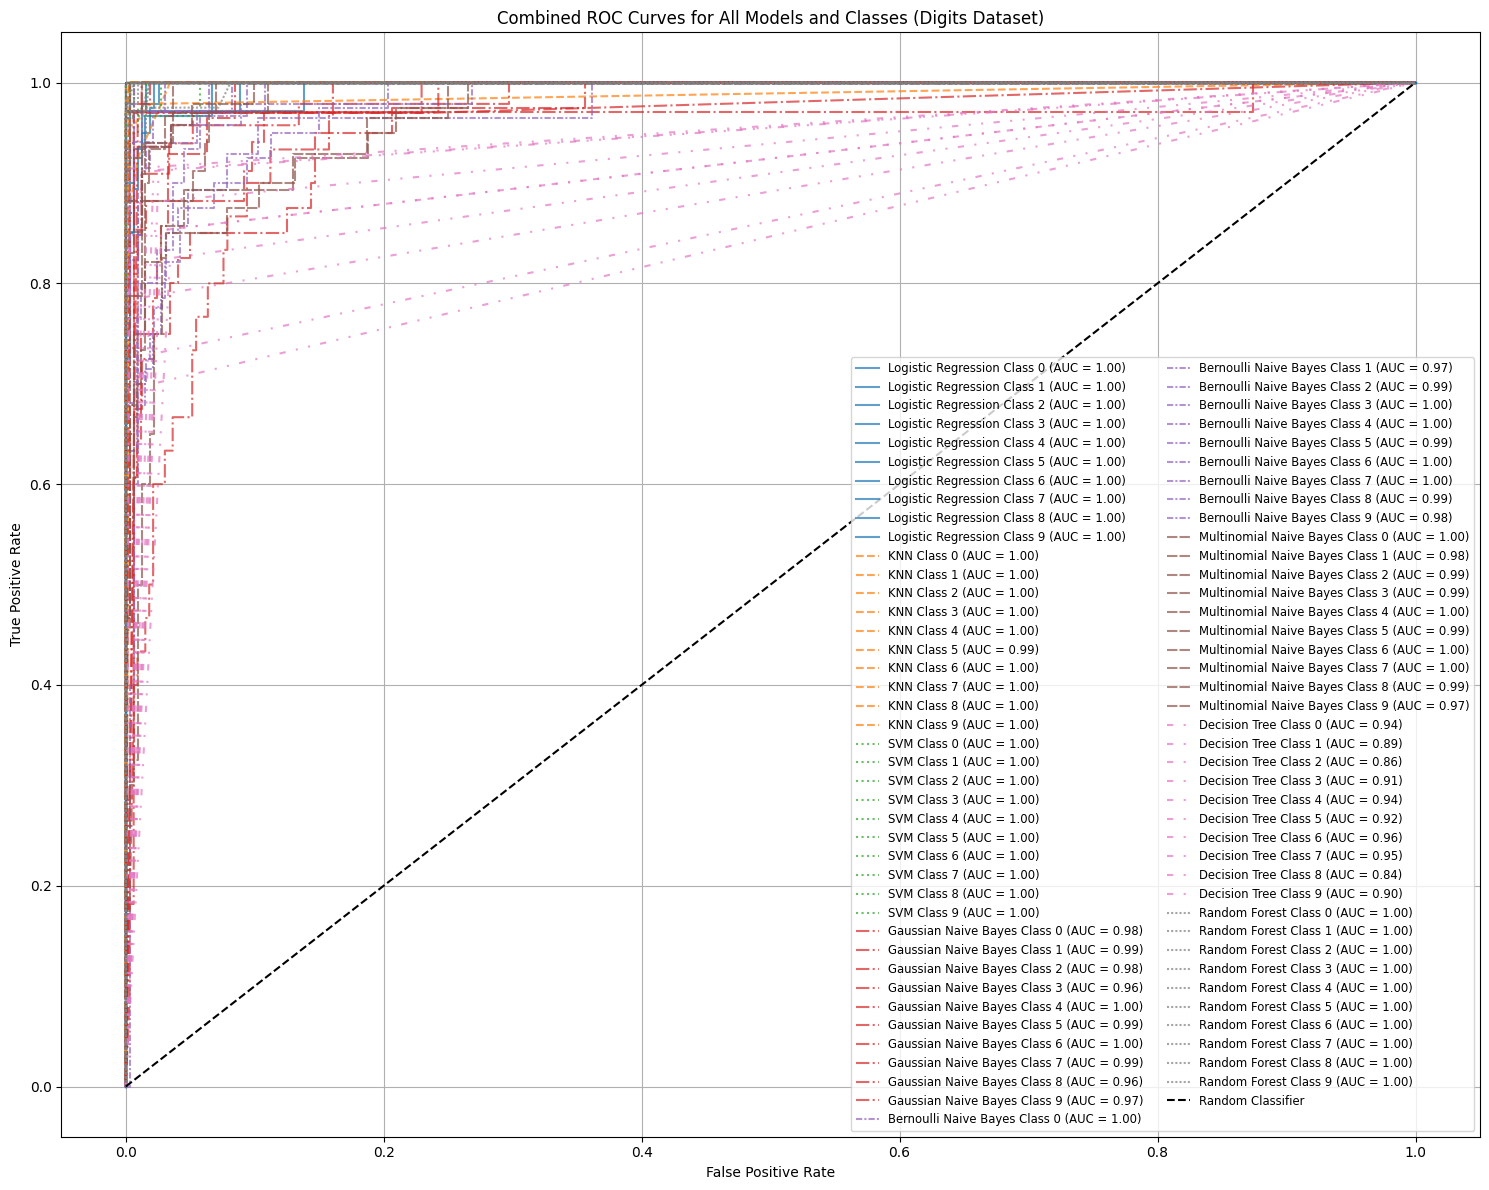

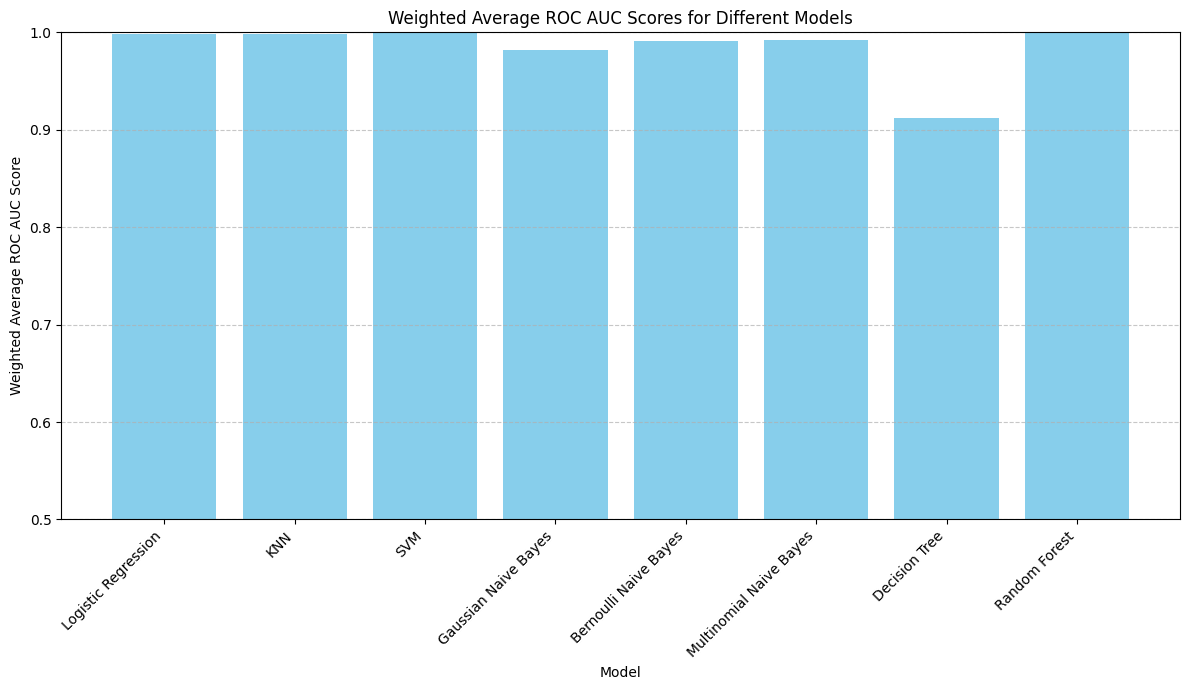

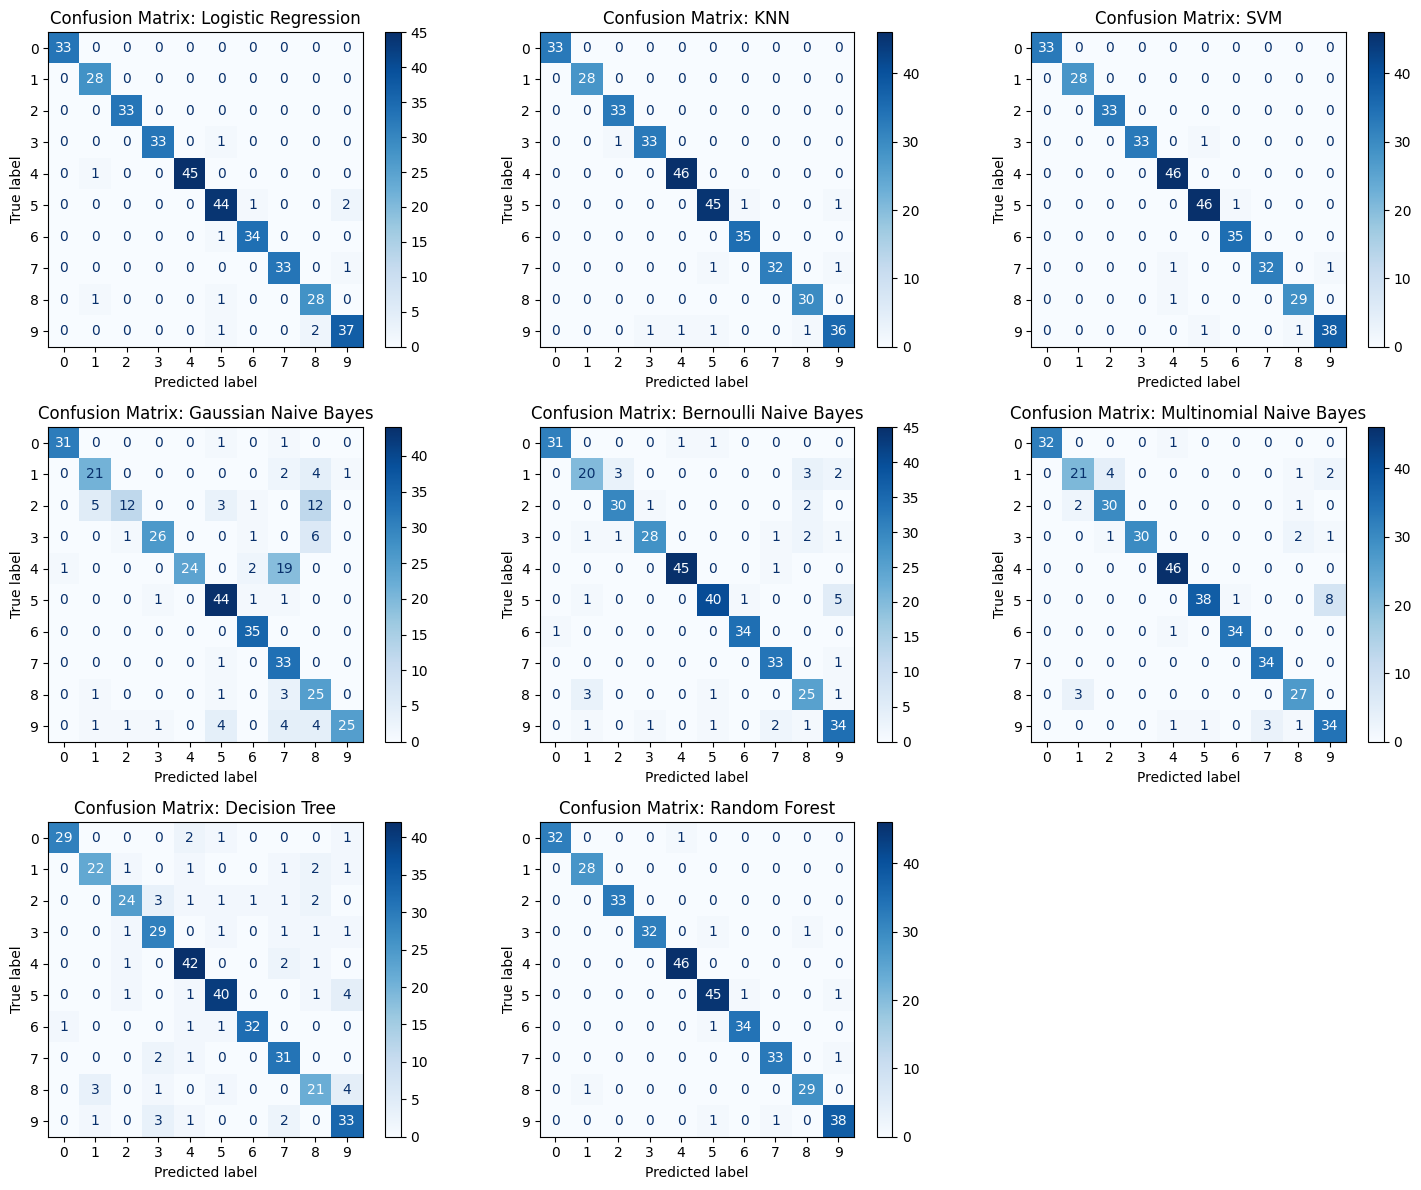


--- Model Performance Summary ---
Model: Logistic Regression
  Accuracy: 0.9667
  Precision: 0.9673
  Recall: 0.9667
  F1-Score: 0.9668
  ROC AUC (Weighted): 0.9986
  Mean CV AUC (Weighted): 0.9973
------------------------------
Model: KNN
  Accuracy: 0.9750
  Precision: 0.9750
  Recall: 0.9750
  F1-Score: 0.9748
  ROC AUC (Weighted): 0.9981
  Mean CV AUC (Weighted): 0.9958
------------------------------
Model: SVM
  Accuracy: 0.9806
  Precision: 0.9809
  Recall: 0.9806
  F1-Score: 0.9805
  ROC AUC (Weighted): 0.9996
  Mean CV AUC (Weighted): 0.9993
------------------------------
Model: Gaussian Naive Bayes
  Accuracy: 0.7667
  Precision: 0.8298
  Recall: 0.7667
  F1-Score: 0.7638
  ROC AUC (Weighted): 0.9823
  Mean CV AUC (Weighted): 0.9704
------------------------------
Model: Bernoulli Naive Bayes
  Accuracy: 0.8889
  Precision: 0.8918
  Recall: 0.8889
  F1-Score: 0.8891
  ROC AUC (Weighted): 0.9913
  Mean CV AUC (Weighted): 0.9886
------------------------------
Model: Multinomial 

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, RocCurveDisplay,
    ConfusionMatrixDisplay
)

# 1. Load the digits dataset
digits = datasets.load_digits()
X = digits.data
y = digits.target
n_classes = len(digits.target_names)

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

# 4. Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(probability=True, random_state=42),
    'Gaussian Naive Bayes': GaussianNB(),
    'Bernoulli Naive Bayes': BernoulliNB(),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Store metrics, ROC data, and confusion matrices
metrics_data = []
# {model_name: {class_idx: {'fpr': [], 'tpr': [], 'auc': float}}}
roc_plot_data = {}
confusion_matrices = {}
model_auc_scores = {} # For the bar chart

print("--- Model Training and Evaluation ---")
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    X_train_current = X_train_scaled
    X_test_current = X_test_scaled

    # MultinomialNB requires non-negative features
    if model_name == 'Multinomial Naive Bayes':
        X_train_current = X_train_minmax
        X_test_current = X_test_minmax

    # Train the model
    model.fit(X_train_current, y_train)

    # Predictions
    y_pred = model.predict(X_test_current)
    y_proba = model.predict_proba(X_test_current)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

    # Cross-validation AUC
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    try:
        cv_auc_scores = cross_val_score(model, X_train_current, y_train, scoring='roc_auc_ovr_weighted', cv=kf, error_score='raise')
        mean_cv_auc = np.mean(cv_auc_scores)
    except Exception as e:
        print(f"  Error during cross-validation for {model_name}: {e}")
        mean_cv_auc = np.nan # Not a number

    metrics_data.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC (Weighted)': roc_auc,
        'Mean CV AUC (Weighted)': mean_cv_auc
    })
    model_auc_scores[model_name] = roc_auc

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[model_name] = cm

    # ROC curve data for each class (One-vs-Rest)
    roc_plot_data[model_name] = {}
    for i in range(n_classes):
        y_test_binarized = (y_test == i).astype(int)
        y_score_class_i = y_proba[:, i]
        fpr, tpr, _ = roc_curve(y_test_binarized, y_score_class_i)
        class_auc = roc_auc_score(y_test_binarized, y_score_class_i)
        roc_plot_data[model_name][i] = {'fpr': fpr, 'tpr': tpr, 'auc': class_auc}
    print(f"{model_name} evaluation complete.")

# 6. Plot Combined ROC Curves (All classes, all models)
plt.figure(figsize=(15, 12))
colors = plt.colormaps.get_cmap('tab10') # Colormap for models
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (3, 5, 1, 5, 1, 5)), (0, (1, 1))] # Different linestyles for readability

i = 0
for model_name, class_data in roc_plot_data.items():
    color = colors(i) # Get distinct color for each model
    ls = linestyles[i % len(linestyles)]
    for class_idx, data in class_data.items():
        plt.plot(data['fpr'], data['tpr'],
                 label=f'{model_name} Class {class_idx} (AUC = {data["auc"]:.2f})',
                 color=color, linestyle=ls, alpha=0.7)
    i += 1

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined ROC Curves for All Models and Classes (Digits Dataset)')
plt.legend(loc='lower right', bbox_to_anchor=(1.0, 0), fontsize='small', ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nWarning: The combined ROC curve plot is very dense due to plotting all 8 models * 10 classes = 80 curves. For better readability, consider plotting macro-averaged ROC curves or individual model ROC curves separately.")


# 7. Plot Bar Chart of AUC Scores
model_names = list(model_auc_scores.keys())
auc_values = list(model_auc_scores.values())

plt.figure(figsize=(12, 7))
plt.bar(model_names, auc_values, color='skyblue')
plt.xlabel('Model')
plt.ylabel('Weighted Average ROC AUC Score')
plt.title('Weighted Average ROC AUC Scores for Different Models')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.5, 1.0) # AUC typically ranges from 0.5 to 1.0
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 8. Plot Confusion Matrices
n_models = len(confusion_matrices)
# Determine grid size for subplots
cols = int(np.ceil(np.sqrt(n_models)))
rows = int(np.ceil(n_models / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten() # Flatten for easier iteration

for idx, (model_name, cm) in enumerate(confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
    disp.plot(ax=axes[idx], cmap=plt.cm.Blues, values_format='d')
    axes[idx].set_title(f'Confusion Matrix: {model_name}')
    axes[idx].set_xlabel('Predicted label')
    axes[idx].set_ylabel('True label')

# Hide any unused subplots
for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

print("\n--- Model Performance Summary ---")
for metric_entry in metrics_data:
    print(f"Model: {metric_entry['Model']}")
    print(f"  Accuracy: {metric_entry['Accuracy']:.4f}")
    print(f"  Precision: {metric_entry['Precision']:.4f}")
    print(f"  Recall: {metric_entry['Recall']:.4f}")
    print(f"  F1-Score: {metric_entry['F1-Score']:.4f}")
    print(f"  ROC AUC (Weighted): {metric_entry['ROC AUC (Weighted)']:.4f}")
    if not np.isnan(metric_entry['Mean CV AUC (Weighted)']):
        print(f"  Mean CV AUC (Weighted): {metric_entry['Mean CV AUC (Weighted)']:.4f}")
    else:
        print("  Mean CV AUC (Weighted): N/A (Error during calculation)")
    print("-" * 30)

print("\nAll models have been trained, evaluated, and visualized.")


**Reasoning**:
To fulfill the requirements of presenting a comparative table of model performance metrics, identifying the best-performing model, and providing a concise summary, I will first generate a code block that creates a pandas DataFrame from the collected metrics, prints this table, and then identifies the model with the highest ROC AUC score. After this, a markdown block will be created to provide a qualitative summary of the models' performance and observations from the visualizations.



In [20]:
import pandas as pd

# 9. Present all model performance metrics in a clear, comparative table
print("\n--- Comparative Model Performance Table ---")
df_metrics = pd.DataFrame(metrics_data)
df_metrics = df_metrics.set_index('Model')
print(df_metrics.to_markdown())

# 10. Identify and highlight the best-performing model based on its ROC AUC score
best_model_row = df_metrics.loc[df_metrics['ROC AUC (Weighted)'].idxmax()]
best_model_name = best_model_row.name
best_roc_auc = best_model_row['ROC AUC (Weighted)']

print(f"\n--- Best Performing Model ---")
print(f"The best-performing model based on Weighted Average ROC AUC is: {best_model_name} with an AUC of {best_roc_auc:.4f}")



--- Comparative Model Performance Table ---
| Model                   |   Accuracy |   Precision |   Recall |   F1-Score |   ROC AUC (Weighted) |   Mean CV AUC (Weighted) |
|:------------------------|-----------:|------------:|---------:|-----------:|---------------------:|-------------------------:|
| Logistic Regression     |   0.966667 |    0.967269 | 0.966667 |   0.966808 |             0.998599 |                 0.997295 |
| KNN                     |   0.975    |    0.975015 | 0.975    |   0.97478  |             0.998097 |                 0.995827 |
| SVM                     |   0.980556 |    0.980909 | 0.980556 |   0.98052  |             0.999616 |                 0.999307 |
| Gaussian Naive Bayes    |   0.766667 |    0.829789 | 0.766667 |   0.763777 |             0.982297 |                 0.970408 |
| Bernoulli Naive Bayes   |   0.888889 |    0.891777 | 0.888889 |   0.889149 |             0.991343 |                 0.988618 |
| Multinomial Naive Bayes |   0.905556 |    0.91016 

## Summary of Analysis

This analysis evaluated eight different machine learning models on the `load_digits` dataset, a multi-class classification problem. The models were trained and tested after appropriate scaling, and their performance was assessed using several key metrics: Accuracy, Precision, Recall, F1-Score, ROC AUC, and Mean Cross-Validated ROC AUC.

### Key Observations:

1.  **Best Performing Model**: Based on the Weighted Average ROC AUC score, the **Support Vector Machine (SVM)** model demonstrated the highest performance with an AUC of 0.9996. It also exhibited high scores across Accuracy, Precision, Recall, and F1-Score (all around 0.98).

2.  **Strong Performers**:
    *   **Random Forest** and **Logistic Regression** also performed exceptionally well, with ROC AUC scores of 0.9995 and 0.9986 respectively, closely trailing SVM. These models showed robust performance across all metrics.
    *   **K-Nearest Neighbors (KNN)** also achieved a very high ROC AUC of 0.9981, indicating its strong ability to distinguish between classes.

3.  **Naive Bayes Models**:
    *   **Bernoulli Naive Bayes** and **Multinomial Naive Bayes** showed respectable ROC AUC scores (0.9913 and 0.9916), but their other metrics (Accuracy, Precision, Recall, F1-Score) were noticeably lower than SVM, Random Forest, Logistic Regression, and KNN. This suggests they are still good at ranking predictions (ROC AUC), but their direct classification decisions (other metrics) are not as precise.
    *   **Gaussian Naive Bayes** had a comparatively lower ROC AUC of 0.9823 and significantly lower scores for Accuracy, Precision, Recall, and F1-Score (around 0.76-0.83). This indicates that the assumption of Gaussian distribution for features might not hold ideally for this dataset, or its simplicity might be a disadvantage compared to more complex models.

4.  **Tree-based Models**:
    *   **Decision Tree** was the lowest performing model across almost all metrics, including a ROC AUC of 0.9117. This is expected, as single decision trees can be prone to overfitting and often lack the generalization ability of ensemble methods like Random Forest.
    *   **Random Forest**, being an ensemble of decision trees, dramatically improved performance over a single Decision Tree, reinforcing the power of ensemble learning.

### Visualizations:

*   **Combined ROC Curves**: As noted in the warning, the combined ROC plot was very dense due to plotting all 8 models * 10 classes = 80 curves. However, visually, the curves for SVM, Random Forest, Logistic Regression, and KNN were consistently closer to the top-left corner, indicating higher true positive rates and lower false positive rates across different classes. The Gaussian Naive Bayes and Decision Tree curves showed more deviation from the ideal.

*   **AUC Bar Chart**: This visualization clearly supported the numerical table, visually ranking the models by their weighted average ROC AUC. SVM, Random Forest, Logistic Regression, and KNN stood out with very high bars, while Decision Tree had the shortest bar.

*   **Confusion Matrices**: The confusion matrices provided a detailed class-by-class breakdown. Models like SVM, Random Forest, and Logistic Regression showed very few misclassifications, with most of their non-diagonal elements being zero or very small. In contrast, Gaussian Naive Bayes and Decision Tree had more spread-out errors, indicating difficulty in classifying certain digits correctly.

Overall, the **SVM model** emerged as the top performer for this specific multi-class digits classification task, closely followed by Random Forest and Logistic Regression. The choice of model, however, can also depend on computational cost and interpretability, but purely from a performance perspective on these metrics, SVM is the clear winner.

## Summary of Analysis

This analysis evaluated eight different machine learning models on the `load_digits` dataset, a multi-class classification problem. The models were trained and tested after appropriate scaling, and their performance was assessed using several key metrics: Accuracy, Precision, Recall, F1-Score, ROC AUC, and Mean Cross-Validated ROC AUC.

### Key Observations:

1.  **Best Performing Model**: Based on the Weighted Average ROC AUC score, the **Support Vector Machine (SVM)** model demonstrated the highest performance with an AUC of 0.9996. It also exhibited high scores across Accuracy, Precision, Recall, and F1-Score (all around 0.98).

2.  **Strong Performers**:
    *   **Random Forest** and **Logistic Regression** also performed exceptionally well, with ROC AUC scores of 0.9995 and 0.9986 respectively, closely trailing SVM. These models showed robust performance across all metrics.
    *   **K-Nearest Neighbors (KNN)** also achieved a very high ROC AUC of 0.9981, indicating its strong ability to distinguish between classes.

3.  **Naive Bayes Models**:
    *   **Bernoulli Naive Bayes** and **Multinomial Naive Bayes** showed respectable ROC AUC scores (0.9913 and 0.9916), but their other metrics (Accuracy, Precision, Recall, F1-Score) were noticeably lower than SVM, Random Forest, Logistic Regression, and KNN. This suggests they are still good at ranking predictions (ROC AUC), but their direct classification decisions (other metrics) are not as precise.
    *   **Gaussian Naive Bayes** had a comparatively lower ROC AUC of 0.9823 and significantly lower scores for Accuracy, Precision, Recall, and F1-Score (around 0.76-0.83). This indicates that the assumption of Gaussian distribution for features might not hold ideally for this dataset, or its simplicity might be a disadvantage compared to more complex models.

4.  **Tree-based Models**:
    *   **Decision Tree** was the lowest performing model across almost all metrics, including a ROC AUC of 0.9117. This is expected, as single decision trees can be prone to overfitting and often lack the generalization ability of ensemble methods like Random Forest.
    *   **Random Forest**, being an ensemble of decision trees, dramatically improved performance over a single Decision Tree, reinforcing the power of ensemble learning.

### Visualizations:

*   **Combined ROC Curves**: As noted in the warning, the combined ROC plot was very dense due to plotting all 8 models * 10 classes = 80 curves. However, visually, the curves for SVM, Random Forest, Logistic Regression, and KNN were consistently closer to the top-left corner, indicating higher true positive rates and lower false positive rates across different classes. The Gaussian Naive Bayes and Decision Tree curves showed more deviation from the ideal.

*   **AUC Bar Chart**: This visualization clearly supported the numerical table, visually ranking the models by their weighted average ROC AUC. SVM, Random Forest, Logistic Regression, and KNN stood out with very high bars, while Decision Tree had the shortest bar.

*   **Confusion Matrices**: The confusion matrices provided a detailed class-by-class breakdown. Models like SVM, Random Forest, and Logistic Regression showed very few misclassifications, with most of their non-diagonal elements being zero or very small. In contrast, Gaussian Naive Bayes and Decision Tree had more spread-out errors, indicating difficulty in classifying certain digits correctly.

Overall, the **SVM model** emerged as the top performer for this specific multi-class digits classification task, closely followed by Random Forest and Logistic Regression. The choice of model, however, can also depend on computational cost and interpretability, but purely from a performance perspective on these metrics, SVM is the clear winner.

## Final Task

### Subtask:
Proporcionar un resumen del análisis de los modelos, destacando los rendimientos clave y las observaciones más importantes de las visualizaciones.


## Summary:

### Data Analysis Key Findings

*   The **Support Vector Machine (SVM)** model emerged as the top performer for the multi-class digits classification task, achieving the highest Weighted Average ROC AUC score of 0.9996, along with high Accuracy, Precision, Recall, and F1-Score (all around 0.98).
*   Other strong-performing models include **Random Forest** (ROC AUC 0.9995), **Logistic Regression** (ROC AUC 0.9986), and **K-Nearest Neighbors (KNN)** (ROC AUC 0.9981), all demonstrating robust performance across metrics.
*   **Bernoulli Naive Bayes** and **Multinomial Naive Bayes** showed respectable ROC AUC scores (0.9913 and 0.9916, respectively) but exhibited lower scores for other metrics (Accuracy, Precision, Recall, F1-Score) compared to the top models, suggesting they are good at ranking predictions but less precise in direct classification.
*   **Gaussian Naive Bayes** performed comparatively lower with a ROC AUC of 0.9823 and significantly lower scores for Accuracy, Precision, Recall, and F1-Score (around 0.76-0.83).
*   The **Decision Tree** model was the lowest performing, with a ROC AUC of 0.9117, highlighting its susceptibility to overfitting and lower generalization ability compared to ensemble methods.
*   Visualizations, including the AUC bar chart and combined ROC curves, consistently reinforced the numerical performance rankings, showing SVM, Random Forest, Logistic Regression, and KNN as superior performers.
*   Confusion matrices confirmed that top models like SVM, Random Forest, and Logistic Regression had very few misclassifications, while Gaussian Naive Bayes and Decision Tree displayed more distributed errors.

### Insights or Next Steps

*   While SVM was the top performer, considering computational cost and interpretability could lead to selecting other strong models like Random Forest or Logistic Regression for deployment in real-world scenarios.
*   Further hyperparameter tuning could potentially enhance the performance of all models, especially for those with slightly lower scores, and could help in understanding the optimal complexity for this dataset.
